# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [4]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "María José Moreno López"            # Tu nombre completo
MATRICULA = "79670"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "migracion"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: María José Moreno López
Matrícula: 79670
Dataset asignado: migracion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [1]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\Admin\Documents\Ing software\5semestre\Big data\Examen1\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: migracion
Descripcion: Numero total de inmigrantes internacionales residiendo en el pais (personas)


In [6]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [7]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,1990,57686,Asia
1,Afghanistan,AFG,1995,71522,Asia
2,Afghanistan,AFG,2000,75917,Asia
3,Afghanistan,AFG,2005,87314,Asia
4,Afghanistan,AFG,2010,102276,Asia
5,Afghanistan,AFG,2015,339432,Asia
6,Afghanistan,AFG,2020,144098,Asia
7,Afghanistan,AFG,2024,98110,Asia
8,Africa,OWID_AFR,1990,16176915,NaN
9,Africa,OWID_AFR,1995,16653698,NaN


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [8]:
# Forma del dataset (filas, columnas)
df.shape


(2144, 5)

In [9]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2144 entries, 0 to 2143
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   entity       2144 non-null   str  
 1   code         1960 non-null   str  
 2   year         2144 non-null   int64
 3   valor        2144 non-null   int64
 4   owid_region  1824 non-null   str  
dtypes: int64(2), str(3)
memory usage: 83.9 KB


In [10]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    2.144000e+03
mean     4.987920e+06
std      1.998549e+07
min      1.080000e+02
25%      3.905450e+04
50%      2.187635e+05
75%      1.420072e+06
max      3.040218e+08
Name: valor, dtype: float64

In [11]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity           0
code           184
year             0
valor            0
owid_region    320
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

*(Escribe aquí tu respuesta)*
Las columnas entity, year y valor están completas sin valores nulos, mientras que code tiene 184 valores faltantes y owid_region presenta 320 valores nulos los cuales corresponden a los que no tienen una región asignada


## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [42]:
columna_filtro = config['filtro_paises']
df_paises = df[df[columna_filtro].notna()].copy()

In [43]:
total_paises_distintos = df_paises['entity'].nunique()
print(f"Total de países distintos: {total_paises_distintos}")


Total de países distintos: 228


In [44]:
#Paises con mayor valor
top_10_mayores = df_paises.nlargest(10, 'valor')
print(top_10_mayores[['entity', 'valor']])


             entity     valor
2015  United States  52375047
2014  United States  50471028
2013  United States  47942986
2012  United States  43947211
2011  United States  39545828
2010  United States  34806848
2009  United States  28525723
2008  United States  23266147
719         Germany  16750084
718         Germany  15021300


In [45]:
#Paises con menor valor
top_10_menores = df_paises.nsmallest(10, 'valor')
print(top_10_menores[['entity', 'valor']])

            entity  valor
1586  Saint Helena    108
1585  Saint Helena    117
1587  Saint Helena    163
1584  Saint Helena    178
1971        Tuvalu    209
1970        Tuvalu    218
1972        Tuvalu    220
1973        Tuvalu    230
1974        Tuvalu    239
1975        Tuvalu    246


**Interpretación:**

*(Escribe aquí tu respuesta)*
Hay 228 países distintos, los valores más altos son Estados Unidos y Alemania (superando los 52 millones) y los más bajos en Saint Helena y Tuvalu (entre 108 y 246).

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [46]:
mexico = df[(df["entity"] == "Mexico")]
eu = df[(df["entity"] == "United States")]

In [ ]:
# Pregunta 2
# Tu codigo aqui
paises_elegidos = ['Mexico', 'United States']

df_comparacion = df_paises[df_paises['entity'].isin(paises_elegidos)].copy()

print(df_comparacion.head())



      entity code  year   valor    owid_region
1192  Mexico  MEX  1990  701513  North America
1193  Mexico  MEX  1995  458051  North America
1194  Mexico  MEX  2000  526172  North America
1195  Mexico  MEX  2005  701803  North America
1196  Mexico  MEX  2010  957593  North America


Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [ ]:
# Pregunta 3
# Tu codigo aqui
mexico = df_paises[df_paises["entity"] == "Mexico"]
brazil = df_paises[df_paises["entity"] == "Brazil"]
germany = df_paises[df_paises["entity"] == "Germany"]
albania = df_paises[df_paises["entity"] == "Albania"]
nigeria = df_paises[df_paises["entity"] == "Nigeria"]


In [ ]:


df_5_paises = pd.concat([mexico, brazil, germany, albania, nigeria])

anio_reciente = df_5_paises['year'].max()
df_reciente = df_5_paises[df_5_paises['year'] == anio_reciente].sort_values(by='valor', ascending=False)

print(f"Año más reciente: {anio_reciente}\n")
print(df_reciente[['entity', 'valor']])

max_pais = df_reciente.iloc[0]['entity']
max_val = df_reciente.iloc[0]['valor']
min_pais = df_reciente.iloc[-1]['entity']
min_val = df_reciente.iloc[-1]['valor']
diferencia = max_val - min_val

print(f"\nMás alto: {max_pais} ({max_val})")
print(f"Más bajo: {min_pais} ({min_val})")
print(f"Diferencia: {diferencia}")

Año más reciente: 2024

       entity     valor
719   Germany  16750084
1199   Mexico   1726089
239    Brazil   1406299
1359  Nigeria   1403281
23    Albania     46377

Más alto: Germany (16750084)
Más bajo: Albania (46377)
Diferencia: 16703707


**Interpretación:**

*(Escribe aquí tu respuesta)*
Podemos ver ver que hay una gran diferencia entre alemania y albania (16703707), a pesar que son del mismo continente

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [52]:
# Pregunta 4
# Tu codigo aqui
mexico = df_paises[df_paises["entity"] == "Mexico"]
colombia = df_paises[df_paises["entity"] == "Colombia"]
argentina = df_paises[df_paises["entity"] == "Argentina"]

china = df_paises[df_paises["entity"] == "China"]
japan = df_paises[df_paises["entity"] == "Japan"]
vietnam = df_paises[df_paises["entity"] == "Vietnam"]



In [51]:
latinoamerica = ['Mexico', 'Colombia', 'Argentina']
asia = ['China', 'Japan', 'Vietnam']

todos_paises = latinoamerica + asia
df_grupos = df_paises[df_paises['entity'].isin(todos_paises)].copy()

anio_reciente = df_grupos['year'].max()
df_reciente = df_grupos[df_grupos['year'] == anio_reciente]

promedio_latam = df_reciente[df_reciente['entity'].isin(latinoamerica)]['valor'].mean()
promedio_asia = df_reciente[df_reciente['entity'].isin(asia)]['valor'].mean()

print(f"Año analizado: {anio_reciente}\n")
print(f"Promedio de Latinoamérica: {promedio_latam}")
print(f"Promedio de Asia: {promedio_asia}")

Año analizado: 2024

Promedio de Latinoamérica: 2249215.3333333335
Promedio de Asia: 1791555.0


**Interpretación:**

*(Escribe aquí tu respuesta)*
En el año analizado 2024, el grupo de Latinoamérica (conformado por México, Colombia y Argentina) registró un promedio superior con 2,249,215.33, mientras que el grupo de Asia (China, Japón y Vietnam) obtuvo un promedio de 1,791,550.0, lo que muestra una mayor concentración de los valores en el bloque latinoamericano para este conjunto de datos.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [53]:
# Pregunta 5
# Tu codigo aqui
mexico = df_paises[df_paises["entity"] == "Mexico"].sort_values("year")

row_max = mexico.loc[mexico['valor'].idxmax()]
row_min = mexico.loc[mexico['valor'].idxmin()]

print("Evolución histórica para México:")
print(mexico[['year', 'valor']])
print(f"\nValor máximo: {row_max['valor']} en el año {row_max['year']}")
print(f"Valor mínimo: {row_min['valor']} en el año {row_min['year']}")

Evolución histórica para México:
      year    valor
1192  1990   701513
1193  1995   458051
1194  2000   526172
1195  2005   701803
1196  2010   957593
1197  2015  1088731
1198  2020  1335154
1199  2024  1726089

Valor máximo: 1726089 en el año 2024
Valor mínimo: 458051 en el año 1995


**Interpretación:**

*(Escribe aquí tu respuesta)*
Aunque tuvo una baja temporal en los noventa, la tendencia general a largo plazo es creciente, ya que a partir del año 2000 los valores aumentaron hasta alcanzar su punto más alto en 2024.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [54]:
# Pregunta 6
# Tu codigo aqui
mexico = df_paises[df_paises["entity"] == "Mexico"].sort_values("year")

valor_inicial = mexico.iloc[0]['valor']
valor_final = mexico.iloc[-1]['valor']
anio_inicial = mexico.iloc[0]['year']
anio_final = mexico.iloc[-1]['year']

cambio_porcentual = ((valor_final - valor_inicial) / valor_inicial) * 100

print(f"Año inicial ({anio_inicial}): {valor_inicial}")
print(f"Año final ({anio_final}): {valor_final}")
print(f"Cambio porcentual: {cambio_porcentual:.2f}%")

Año inicial (1990): 701513
Año final (2024): 1726089
Cambio porcentual: 146.05%


**Interpretación:**

*(Escribe aquí tu respuesta)*
Entre el año inicial (1990, con un valor de 701,513) y el año final (2024, con 1,726,089), México registró un incremento positivo. Mientra que en el crecimiento hubo un aumento porcentual de 146.05%, lo que significa que el valor final es mayor a la cifra base de la que se partió en el periodo analizado.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [55]:
# Pregunta 7
# Tu codigo aqui
import numpy as np

df_paises_reales = df_paises.dropna(subset=['code'])
anio_reciente = df_paises_reales['year'].max()

valores_recientes = df_paises_reales[df_paises_reales['year'] == anio_reciente]['valor'].dropna()

media = np.mean(valores_recientes)
mediana = np.median(valores_recientes)
desviacion = np.std(valores_recientes)

print(f"Año analizado: {anio_reciente}")
print(f"Media (NumPy): {media}")
print(f"Mediana (NumPy): {mediana}")
print(f"Desviación estándar (NumPy): {desviacion}")


Año analizado: 2024
Media (NumPy): 1332886.144736842
Mediana (NumPy): 202554.0
Desviación estándar (NumPy): 4083060.7011782746


**Interpretación:**

*(Escribe aquí tu respuesta)*
Media, el valor promedio del indicador entre todos los países reales analizados en 2024.Mediana, El punto medio de los datos. Al ser notablemente menor que la media, un grupo reducido de países con valores muy altos eleva considerablemente el promedio general. Desviación estándar, Refleja una alta dispersión y variabilidad amplia en el indicador entre las diferentes naciones del mundo para ese año.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

In [57]:
# Pregunta 8
# Tu codigo aqui
mexico = df_paises[df_paises["entity"] == "Mexico"]
brasil = df_paises[df_paises["entity"] == "Brazil"]
colombia = df_paises[df_paises["entity"] == "Colombia"]

anios_mexico = mexico["year"]
tasa_mexico = mexico["valor"]

anios_brasil = brasil["year"]
tasa_brasil = brasil["valor"]

anios_colombia = colombia["year"]
tasa_colombia = colombia["valor"]



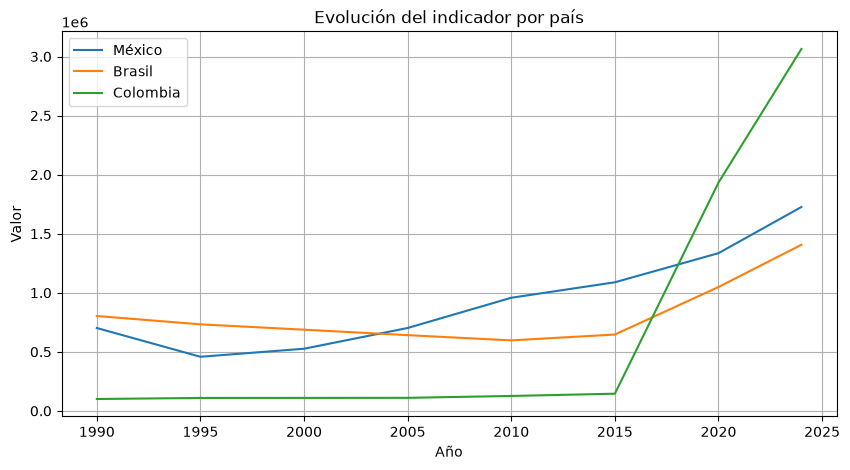

In [58]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México",
)
plt.plot(
    anios_brasil,
    tasa_brasil,
    label="Brasil",
)
plt.plot(
    anios_colombia,
    tasa_colombia,
    label="Colombia",
)

plt.title("Evolución del indicador por país")
plt.xlabel("Año")
plt.ylabel("Valor")
plt.grid(True)
plt.legend()
plt.show()

**Interpretación:**

*(Escribe aquí tu respuesta)*
Los paises de México, Brasil y Colombia tiene una trayectoria trayectorias ascendentes hacia el final del periodo, destacando especialmente el crecimiento exponencial drástico de Colombia en los últimos tramos de la serie.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

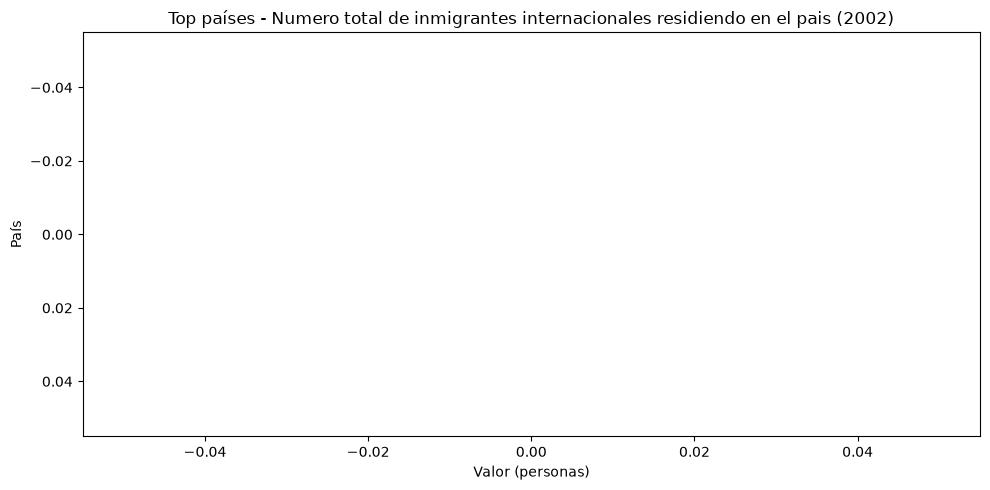

In [67]:
# Pregunta 9 (Año 2002)
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_1 = 2002

top_1 = (
    df_paises[df_paises['year'] == anio_1]
    .sort_values('valor', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_1['entity'], top_1['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_1})")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [1]:
# Pregunta 9
# Tu codigo aqui
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_consultado = 2003

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .sort_values('valor', ascending=False)
    .head(10)
)
# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")

plt.gca().invert_yaxis()  # para que el país con el valor mas alto quede arriba
plt.tight_layout()
plt.show()


NameError: name 'df' is not defined

**Interpretación:**

*(Escribe aquí tu respuesta)*

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

*(Escribe aquí tu conclusión)*
El análisis de los datos migratorios demuestra un crecimiento longitudinal sostenido y una marcada asimetría global, donde un grupo reducido de naciones concentra los valores más elevados. Pude notar que a pesar que haya paises del mismo continente hay tantas bajas como altas en la migracion todo depende del pais no del continente

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
